In [ ]:
import numpy as np
import pandas as pd
import pywt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


def extract_wavelet_features(flux_data, wavelet="db4", level=4):
    """
    Extract wavelet features from flux time series
    """
    # Perform wavelet decomposition
    coeffs = pywt.wavedec(flux_data, wavelet, level=level)

    # Extract features from each coefficient level
    features = []
    for coeff in coeffs:
        features.extend(
            [
                np.mean(coeff),
                np.std(coeff),
                np.max(coeff),
                np.min(coeff),
                np.median(coeff),
            ]
        )

    return features


def process_dataset(data):
    """
    Process entire dataset and extract features
    """
    X = []
    for i in range(len(data)):
        flux_features = extract_wavelet_features(data[i])
        X.append(flux_features)
    return np.array(X)


# Assuming your data is in a pandas DataFrame where each row is a star
# and columns are flux measurements, plus a 'label' column indicating planet presence
def train_planet_detector(df, label_column="label"):
    # Separate features and labels
    X = df.drop(columns=[label_column])
    y = df[label_column]

    # Extract wavelet features
    X_processed = process_dataset(X.values)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42
    )

    # Train model
    clf = RandomForestClassifier(n_estimators=100)
    clf.fit(X_train, y_train)

    return clf, X_test, y_test

In [ ]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 34.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("exoTrain.csv")

In [ ]:
train_planet_detector(df, label_column="LABEL")

(RandomForestClassifier(),
 array([[-1.87550251e+00,  3.29286890e+01,  1.75574441e+02, ...,
          8.50531270e+01, -1.66499552e+02,  3.73062098e-02],
        [-2.06791906e+01,  4.31426209e+02,  1.13454294e+03, ...,
          2.54893772e+02, -5.26304636e+02, -4.68439491e-01],
        [-6.75697400e+00,  1.67824825e+02,  3.00040609e+02, ...,
          6.32025628e+02, -7.51121294e+01, -1.47178494e-01],
        ...,
        [ 5.46800532e-01,  2.16086669e+01,  1.72834447e+02, ...,
          4.96477617e+02, -3.52524622e+01, -5.97839718e-02],
        [ 1.71769861e+01,  7.75997518e+01,  4.13457910e+02, ...,
          4.23579232e+02, -5.74173692e+01, -2.36280868e-01],
        [ 3.05279895e+00,  1.48736818e+01,  1.03991343e+02, ...,
          3.71630419e+02, -4.48953336e+01,  6.57255966e-02]]),
 589     1
 1029    1
 33      2
 2133    1
 2153    1
        ..
 1832    1
 3131    1
 3482    1
 517     1
 5085    1
 Name: LABEL, Length: 1018, dtype: int64)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)


def evaluate_model(clf, X_test, y_test):
    """
    Evaluate model performance on test set with multiple metrics and visualizations
    """
    # Get predictions
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.2f})"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower right")
    plt.show()

    return {
        "predictions": y_pred,
        "probabilities": y_pred_proba,
        "confusion_matrix": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


# Example usage with your previous code:
def main():
    # Assuming df is your DataFrame with flux data and labels
    clf, X_test, y_test = train_planet_detector(df, "LABEL")

    # Evaluate the model
    results = evaluate_model(clf, X_test, y_test)

    # Print additional metrics
    print("\nDetailed Results:")
    print(f"ROC AUC: {results['roc_auc']:.3f}")
    print(f"PR AUC: {results['pr_auc']:.3f}")

    # If you want to examine specific false positives or false negatives
    fp_indices = np.where((y_test == 0) & (results["predictions"] == 1))[0]
    fn_indices = np.where((y_test == 1) & (results["predictions"] == 0))[0]

    print(f"\nNumber of False Positives: {len(fp_indices)}")
    print(f"Number of False Negatives: {len(fn_indices)}")

    # Optional: Plot some misclassified examples
    def plot_misclassified_example(index, original_data):
        plt.figure(figsize=(10, 4))
        plt.plot(original_data[index])
        plt.title(f"{'False Positive' if index in fp_indices else 'False Negative'}")
        plt.show()

    # Uncomment to plot first few misclassified examples
    # for idx in fp_indices[:3]:
    #     plot_misclassified_example(idx, original_flux_data)


Classification Report:
              precision    recall  f1-score   support

           1       0.99      1.00      1.00      1010
           2       0.00      0.00      0.00         8

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.98      0.99      0.99      1018



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


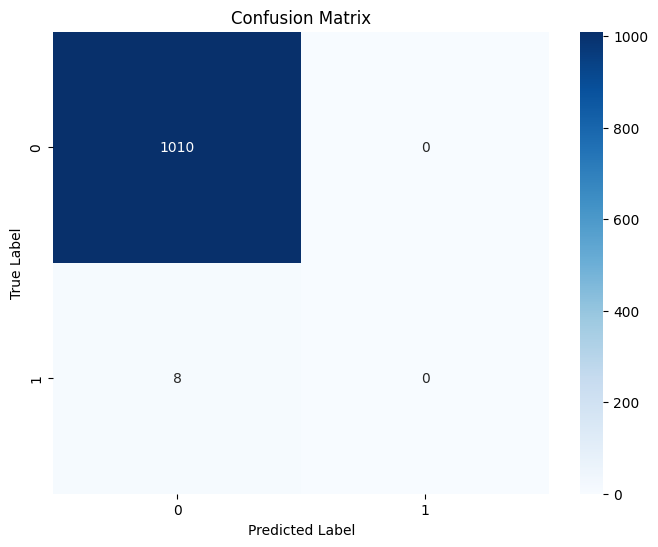

ValueError: y_true takes value in {1, 2} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
main()

In [ ]:
def extract_wavelet_features(flux_data, wavelet="db4", level=4):
    """
    Extract wavelet features from flux time series
    """
    # Perform wavelet decomposition
    coeffs = pywt.wavedec(flux_data, wavelet, level=level)

    # Extract features from each coefficient level
    features = []
    for coeff in coeffs:
        features.extend(
            [
                np.mean(coeff),
                np.std(coeff),
                np.max(coeff),
                np.min(coeff),
                np.median(coeff),
            ]
        )

    return features


def process_dataset(data):
    """
    Process entire dataset and extract features
    """
    X = []
    for i in range(len(data)):
        flux_features = extract_wavelet_features(data[i])
        X.append(flux_features)
    return np.array(X)


def train_planet_detector(df, label_column="label"):
    # Separate features and labels
    X = df.drop(columns=[label_column])
    y = df[label_column]

    # Convert labels from {1,2} to {0,1}
    y = (y == 2).astype(int)  # Assuming 2 is the "planet" class

    # Extract wavelet features
    X_processed = process_dataset(X.values)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42
    )

    # Train model
    clf = RandomForestClassifier(n_estimators=100)
    clf.fit(X_train, y_train)

    return clf, X_test, y_test


def evaluate_model(clf, X_test, y_test):
    """
    Evaluate model performance on test set
    """
    # Get predictions
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.2f})"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower right")
    plt.show()

    return {
        "predictions": y_pred,
        "probabilities": y_pred_proba,
        "confusion_matrix": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


def main():
    # Assuming df is your DataFrame with flux data and labels
    clf, X_test, y_test = train_planet_detector(df, "LABEL")

    # Evaluate the model
    results = evaluate_model(clf, X_test, y_test)

    # Print additional metrics
    print("\nDetailed Results:")
    print(f"ROC AUC: {results['roc_auc']:.3f}")
    print(f"PR AUC: {results['pr_auc']:.3f}")

    # If you want to examine specific false positives or false negatives
    fp_indices = np.where((y_test == 0) & (results["predictions"] == 1))[0]
    fn_indices = np.where((y_test == 1) & (results["predictions"] == 0))[0]

    print(f"\nNumber of False Positives: {len(fp_indices)}")
    print(f"Number of False Negatives: {len(fn_indices)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1010
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.98      0.99      0.99      1018



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


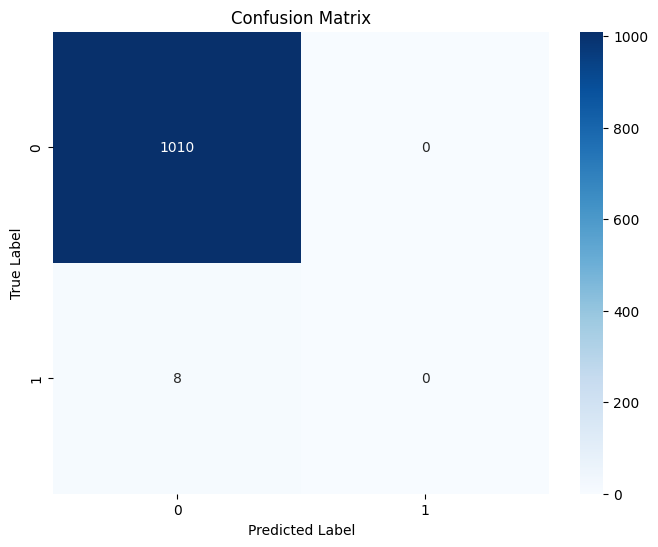

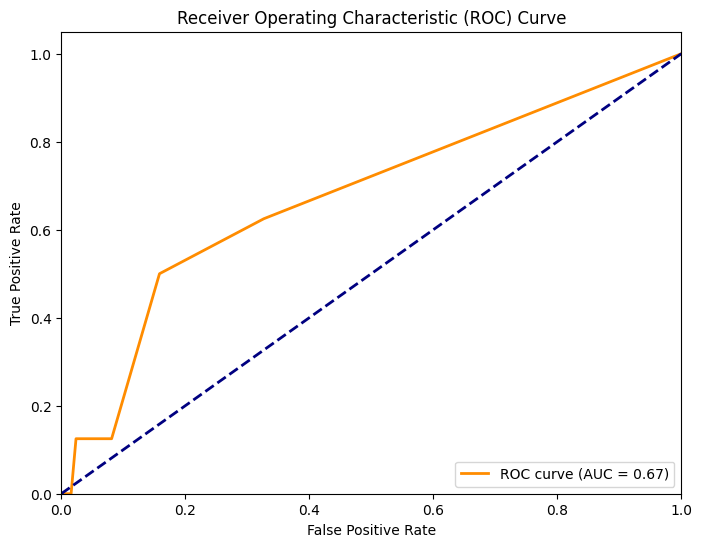

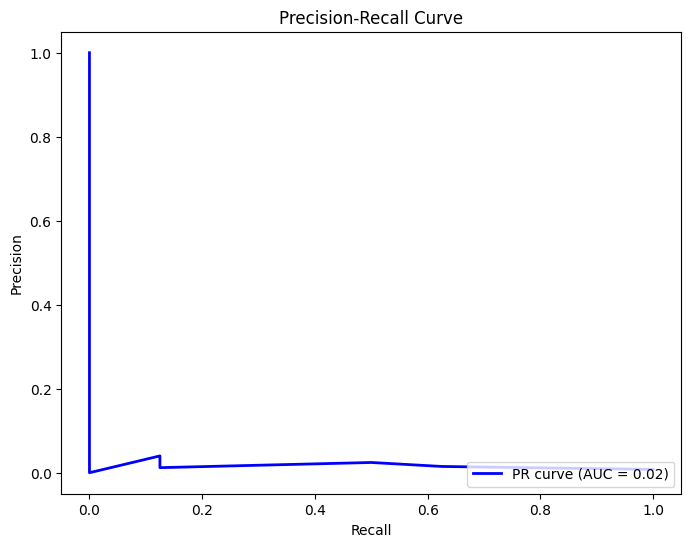


Detailed Results:
ROC AUC: 0.674
PR AUC: 0.016

Number of False Positives: 0
Number of False Negatives: 8


In [ ]:
main()

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


def extract_wavelet_features(flux_data, wavelet="db4", level=4):
    """
    Extract wavelet features from flux time series
    """
    coeffs = pywt.wavedec(flux_data, wavelet, level=level)

    features = []
    for coeff in coeffs:
        features.extend(
            [
                np.mean(coeff),
                np.std(coeff),
                np.max(coeff),
                np.min(coeff),
                np.median(coeff),
            ]
        )

    return features


def process_dataset(data):
    """
    Process entire dataset and extract features
    """
    X = []
    for i in range(len(data)):
        flux_features = extract_wavelet_features(data[i])
        X.append(flux_features)
    return np.array(X)


def train_planet_detector(df, label_column="label"):
    # Separate features and labels
    X = df.drop(columns=[label_column])
    y = df[label_column]

    # Convert labels to categorical
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Create meaningful class names
    class_names = ["No Planet", "Planet"]  # Modified this line

    # Extract wavelet features
    X_processed = process_dataset(X.values)

    # First split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE only to the training data
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    # Print class distribution before and after SMOTE
    print("\nClass distribution before SMOTE:")
    print(pd.Series(y_train).value_counts(normalize=True))
    print("\nClass distribution after SMOTE:")
    print(pd.Series(y_train_balanced).value_counts(normalize=True))

    # Train model on balanced data
    clf = RandomForestClassifier(n_estimators=100, class_weight="balanced")
    clf.fit(X_train_balanced, y_train_balanced)

    return clf, X_test, y_test, class_names


def evaluate_model(clf, X_test, y_test, class_names):
    """
    Evaluate model performance on test set
    """
    # Get predictions
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Print classification report with class names
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.2f})"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower right")
    plt.show()

    return {
        "predictions": y_pred,
        "probabilities": y_pred_proba,
        "confusion_matrix": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


def main():
    # Assuming df is your DataFrame with flux data and labels
    clf, X_test, y_test, class_names = train_planet_detector(df, "LABEL")

    # Evaluate the model
    results = evaluate_model(clf, X_test, y_test, class_names)

    # Print additional metrics
    print("\nDetailed Results:")
    print(f"ROC AUC: {results['roc_auc']:.3f}")
    print(f"PR AUC: {results['pr_auc']:.3f}")

    # Examine false positives and negatives
    fp_indices = np.where((y_test == 0) & (results["predictions"] == 1))[0]
    fn_indices = np.where((y_test == 1) & (results["predictions"] == 0))[0]

    print(f"\nNumber of False Positives: {len(fp_indices)}")
    print(f"Number of False Negatives: {len(fn_indices)}")


Class distribution before SMOTE:
0    0.992627
1    0.007373
Name: proportion, dtype: float64

Class distribution after SMOTE:
0    0.5
1    0.5
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

   No Planet       0.99      0.99      0.99      1011
      Planet       0.00      0.00      0.00         7

    accuracy                           0.98      1018
   macro avg       0.50      0.49      0.50      1018
weighted avg       0.99      0.98      0.98      1018



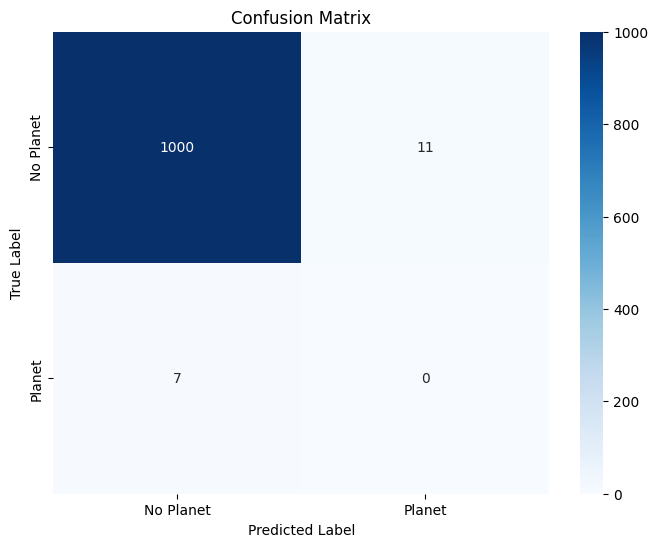

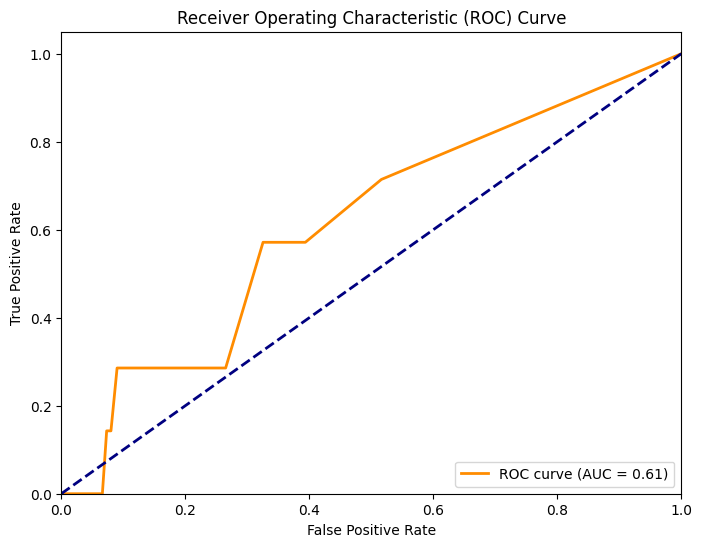

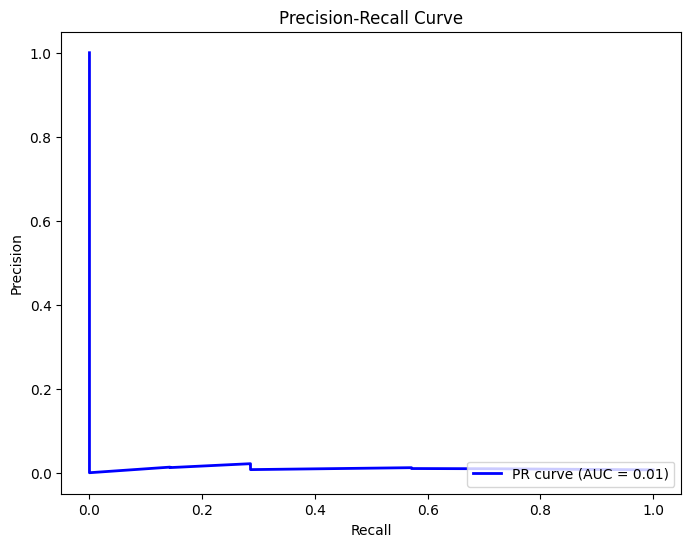


Detailed Results:
ROC AUC: 0.612
PR AUC: 0.010

Number of False Positives: 11
Number of False Negatives: 7


In [ ]:
main()

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler


def extract_wavelet_features(flux_data, wavelet="db4", level=4):
    """
    Extract wavelet features from flux time series
    """
    coeffs = pywt.wavedec(flux_data, wavelet, level=level)

    features = []
    for coeff in coeffs:
        features.extend(
            [
                np.mean(coeff),
                np.std(coeff),
                np.max(coeff),
                np.min(coeff),
                np.median(coeff),
                np.percentile(coeff, 25),
                np.percentile(coeff, 75),
                np.sum(np.abs(coeff)),  # Added energy feature
                np.sqrt(np.mean(coeff**2)),  # Added RMS feature
            ]
        )

    return features


def process_dataset(data):
    """
    Process entire dataset and extract features
    """
    X = []
    for i in range(len(data)):
        flux_features = extract_wavelet_features(data[i])
        X.append(flux_features)
    return np.array(X)


def train_planet_detector(df, label_column="label"):
    # Print initial class distribution
    print("\nInitial class distribution:")
    print(df[label_column].value_counts(normalize=True))

    # Separate features and labels
    X = df.drop(columns=[label_column])
    y = df[label_column]

    # Convert labels to categorical
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Create meaningful class names
    class_names = ["No Planet", "Planet"]

    # Extract wavelet features
    X_processed = process_dataset(X.values)

    # Scale features
    scaler = StandardScaler()
    X_processed = scaler.fit_transform(X_processed)

    # First split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE with adjusted parameters
    smote = SMOTE(random_state=42, sampling_strategy=0.4)  # Adjusted ratio
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    # Print class distribution after SMOTE
    print("\nClass distribution after SMOTE:")
    print(pd.Series(y_train_balanced).value_counts(normalize=True))

    # Train model with adjusted parameters
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
    )

    # Perform cross-validation
    cv_scores = cross_val_score(clf, X_train_balanced, y_train_balanced, cv=5)
    print("\nCross-validation scores:", cv_scores)
    print("Mean CV score:", cv_scores.mean())

    # Fit the model
    clf.fit(X_train_balanced, y_train_balanced)

    # Feature importance analysis
    feature_importance = pd.DataFrame(
        {"feature": range(X_processed.shape[1]), "importance": clf.feature_importances_}
    ).sort_values("importance", ascending=False)

    print("\nTop 10 most important features:")
    print(feature_importance.head(10))

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(10), feature_importance["importance"][:10])
    plt.title("Top 10 Feature Importance")
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")
    plt.show()

    return clf, X_test, y_test, class_names


def evaluate_model(clf, X_test, y_test, class_names):
    """
    Evaluate model performance on test set
    """
    # Get predictions
    clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Adjust probability threshold
    thresholds = np.arange(0.1, 0.9, 0.1)
    best_threshold = 0.5
    best_f1 = 0

    print("\nTesting different probability thresholds:")
    for threshold in thresholds:
        y_pred_threshold = (y_pred_proba >= threshold).astype(int)
        report = classification_report(y_test, y_pred_threshold, output_dict=True)
        f1 = report["1"]["f1-score"]  # assuming 1 is the planet class
        print(f"Threshold: {threshold:.1f}, F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"\nBest threshold: {best_threshold}")
    y_pred_final = (y_pred_proba >= best_threshold).astype(int)

    # Print classification report with class names
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_final, target_names=class_names))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.2f})"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower right")
    plt.show()

    return {
        "predictions": y_pred_final,
        "probabilities": y_pred_proba,
        "confusion_matrix": cm,
        "best_threshold": best_threshold,
    }


def main():
    # Load your data
    # df = pd.read_csv('your_data.csv')

    # Print shape and basic info
    print("Dataset shape:", df.shape)
    print("\nSample of first few rows:")
    print(df.head())

    # Train and evaluate
    clf, X_test, y_test, class_names = train_planet_detector(df, "LABEL")
    evaluate_model(clf, X_test, y_test, class_names)


if __name__ == "__main__":
    main()

Dataset shape: (5087, 3198)

Sample of first few rows:
   LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4   FLUX.5   FLUX.6  FLUX.7  \
0      2    93.85    83.81    20.10   -26.98   -39.56  -124.71 -135.18   
1      2   -38.88   -33.83   -58.54   -40.09   -79.31   -72.81  -86.55   
2      2   532.64   535.92   513.73   496.92   456.45   466.00  464.50   
3      2   326.52   347.39   302.35   298.13   317.74   312.70  322.33   
4      2 -1107.21 -1112.59 -1118.95 -1095.10 -1057.55 -1034.48 -998.34   

    FLUX.8  FLUX.9  ...  FLUX.3188  FLUX.3189  FLUX.3190  FLUX.3191  \
0   -96.27  -79.89  ...     -78.07    -102.15    -102.15      25.13   
1   -85.33  -83.97  ...      -3.28     -32.21     -32.21     -24.89   
2   486.39  436.56  ...     -71.69      13.31      13.31     -29.89   
3   311.31  312.42  ...       5.71      -3.73      -3.73      30.05   
4 -1022.71 -989.57  ...    -594.37    -401.66    -401.66    -357.24   

   FLUX.3192  FLUX.3193  FLUX.3194  FLUX.3195  FLUX.3196  FLUX.3197  
0  

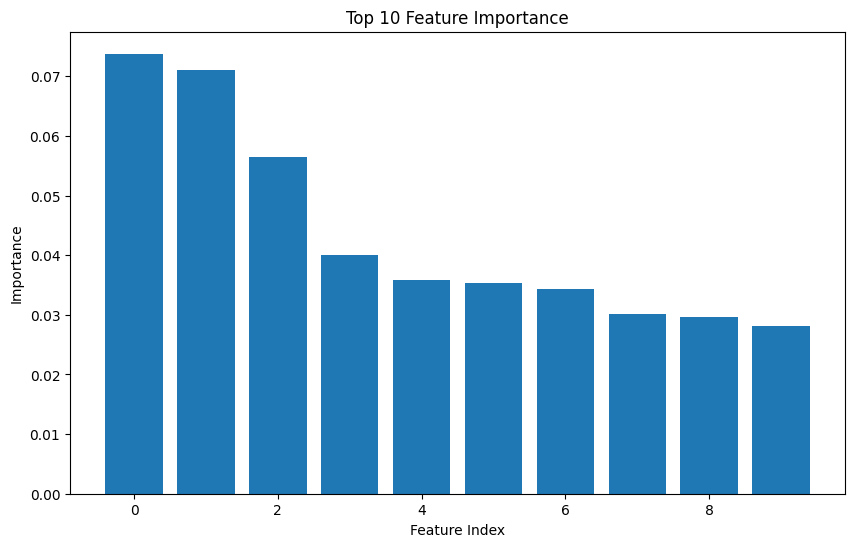


Testing different probability thresholds:
Threshold: 0.1, F1: 0.016
Threshold: 0.2, F1: 0.000
Threshold: 0.3, F1: 0.000
Threshold: 0.4, F1: 0.000
Threshold: 0.5, F1: 0.000
Threshold: 0.6, F1: 0.000
Threshold: 0.7, F1: 0.000
Threshold: 0.8, F1: 0.000

Best threshold: 0.1

Classification Report:
              precision    recall  f1-score   support

   No Planet       0.99      0.89      0.94      1011
      Planet       0.01      0.14      0.02         7

    accuracy                           0.88      1018
   macro avg       0.50      0.52      0.48      1018
weighted avg       0.99      0.88      0.93      1018



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


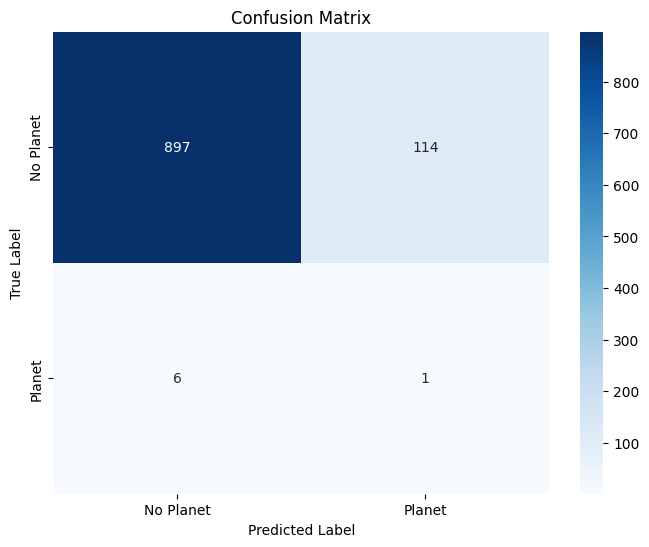

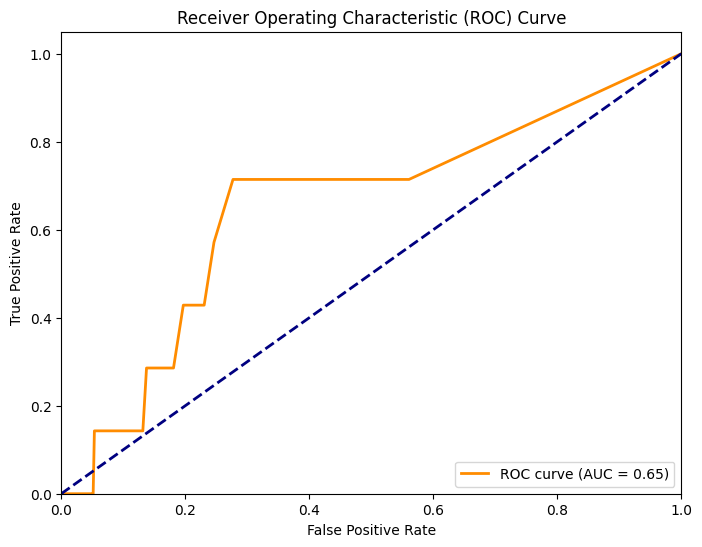

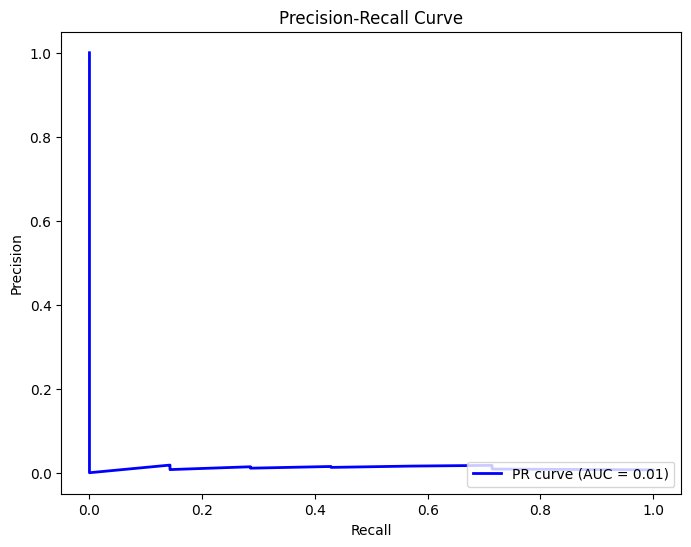

In [ ]:
main()

In [ ]:
import logging
from typing import Any

import pandas as pd
from numpy.typing import NDArray
from sklearn.base import BaseEstimator

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def extract_wavelet_features(
    flux_data: NDArray[np.float64], wavelet: str = "db4", level: int = 4
) -> list[float]:
    """
    Extract wavelet features from flux time series data.

    Parameters
    ----------
    flux_data : np.ndarray
        1D array containing flux measurements over time
    wavelet : str, optional
        Wavelet type to use for decomposition (default: 'db4')
    level : int, optional
        Level of wavelet decomposition (default: 4)

    Returns
    -------
    List[float]
        List of extracted features including statistical measures of wavelet coefficients

    Raises
    ------
    ValueError
        If wavelet decomposition fails or input data is invalid
    """
    try:
        coeffs = pywt.wavedec(flux_data, wavelet, level=level)
        features = []
        for coeff in coeffs:
            features.extend(
                [
                    np.mean(coeff),
                    np.std(coeff),
                    np.max(coeff),
                    np.min(coeff),
                    np.median(coeff),
                    np.percentile(coeff, 25),
                    np.percentile(coeff, 75),
                    np.sum(np.abs(coeff)),
                    np.sqrt(np.mean(coeff**2)),
                ]
            )
        return features
    except Exception as e:
        raise ValueError(f"Error processing wavelet features: {str(e)}")


def process_dataset(data: NDArray[np.float64]) -> NDArray[np.float64]:
    """
    Process entire dataset and extract wavelet features for each time series.

    Parameters
    ----------
    data : np.ndarray
        2D array where each row is a time series of flux measurements

    Returns
    -------
    np.ndarray
        2D array of extracted features for each time series

    Raises
    ------
    ValueError
        If input data is empty or has incorrect dimensions
    """
    if data.size == 0:
        raise ValueError("Empty input data")

    try:
        X = []
        for i in range(len(data)):
            flux_features = extract_wavelet_features(data[i])
            X.append(flux_features)
        return np.array(X)
    except Exception as e:
        raise ValueError(f"Error processing dataset: {str(e)}")


def train_planet_detector(
    df: pd.DataFrame, label_column: str = "label"
) -> tuple[BaseEstimator, NDArray[np.float64], NDArray[np.int64], list[str]]:
    """
    Train a Random Forest classifier for planet detection.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing flux measurements and labels
    label_column : str, optional
        Name of the column containing class labels (default: 'label')

    Returns
    -------
    Tuple[BaseEstimator, np.ndarray, np.ndarray, List[str]]
        Returns (trained_classifier, X_test, y_test, class_names)

    Raises
    ------
    ValueError
        If DataFrame is empty or label_column is not found
    """
    if df.empty:
        raise ValueError("Empty DataFrame provided")
    if label_column not in df.columns:
        raise ValueError(f"Label column '{label_column}' not found in DataFrame")

    # Print initial class distribution
    logger.info("\nInitial class distribution:")
    logger.info(df[label_column].value_counts(normalize=True))

    # Separate features and labels
    X = df.drop(columns=[label_column])
    y = df[label_column]

    # Convert labels to categorical
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Create meaningful class names
    class_names = ["No Planet", "Planet"]

    # Extract wavelet features
    X_processed = process_dataset(X.values)

    # Scale features
    scaler = StandardScaler()
    X_processed = scaler.fit_transform(X_processed)

    # First split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE
    smote = SMOTE(random_state=42, sampling_strategy=0.4)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    # Print class distribution after SMOTE
    logger.info("\nClass distribution after SMOTE:")
    logger.info(pd.Series(y_train_balanced).value_counts(normalize=True))

    # Train model
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
    )

    # Perform cross-validation
    cv_scores = cross_val_score(clf, X_train_balanced, y_train_balanced, cv=5)
    logger.info("\nCross-validation scores: %s", cv_scores)
    logger.info("Mean CV score: %f", cv_scores.mean())

    # Fit the model
    clf.fit(X_train_balanced, y_train_balanced)

    # Feature importance analysis
    feature_importance = pd.DataFrame(
        {"feature": range(X_processed.shape[1]), "importance": clf.feature_importances_}
    ).sort_values("importance", ascending=False)

    logger.info("\nTop 10 most important features:")
    logger.info(feature_importance.head(10))

    plot_feature_importance(feature_importance)

    return clf, X_test, y_test, class_names


def plot_feature_importance(feature_importance: pd.DataFrame) -> None:
    """
    Plot top 10 feature importance.

    Parameters
    ----------
    feature_importance : pd.DataFrame
        DataFrame containing feature importance scores

    Returns
    -------
    None
        Displays the feature importance plot
    """
    plt.figure(figsize=(10, 6))
    plt.bar(range(10), feature_importance["importance"][:10])
    plt.title("Top 10 Feature Importance")
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")
    plt.show()


def plot_confusion_matrix(cm: NDArray[np.int64], class_names: list[str]) -> None:
    """
    Plot confusion matrix as a heatmap.

    Parameters
    ----------
    cm : np.ndarray
        Confusion matrix
    class_names : List[str]
        Names of the classes

    Returns
    -------
    None
        Displays the confusion matrix plot
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


def plot_roc_curve(
    y_test: NDArray[np.int64], y_pred_proba: NDArray[np.float64]
) -> None:
    """
    Plot ROC curve with AUC score.

    Parameters
    ----------
    y_test : np.ndarray
        True test labels
    y_pred_proba : np.ndarray
        Predicted probabilities

    Returns
    -------
    None
        Displays the ROC curve plot
    """
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()


def plot_precision_recall_curve(
    y_test: NDArray[np.int64], y_pred_proba: NDArray[np.float64]
) -> None:
    """
    Plot Precision-Recall curve with AUC score.

    Parameters
    ----------
    y_test : np.ndarray
        True test labels
    y_pred_proba : np.ndarray
        Predicted probabilities

    Returns
    -------
    None
        Displays the Precision-Recall curve plot
    """
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.2f})"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower right")
    plt.show()


def evaluate_model(
    clf: BaseEstimator,
    X_test: NDArray[np.float64],
    y_test: NDArray[np.int64],
    class_names: list[str],
) -> dict[str, Any]:
    """
    Evaluate model performance using multiple metrics and visualizations.

    Parameters
    ----------
    clf : BaseEstimator
        Trained classifier
    X_test : np.ndarray
        Test feature matrix
    y_test : np.ndarray
        True test labels
    class_names : List[str]
        Names of the classes for visualization

    Returns
    -------
    Dict[str, Any]
        Dictionary containing evaluation metrics and predictions
    """
    # Get predictions
    clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Adjust probability threshold
    thresholds = np.arange(0.1, 0.9, 0.1)
    best_threshold = 0.5
    best_f1 = 0

    logger.info("\nTesting different probability thresholds:")
    for threshold in thresholds:
        y_pred_threshold = (y_pred_proba >= threshold).astype(int)
        report = classification_report(y_test, y_pred_threshold, output_dict=True)
        f1 = report["1"]["f1-score"]
        logger.info(f"Threshold: {threshold:.1f}, F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    logger.info(f"\nBest threshold: {best_threshold}")
    y_pred_final = (y_pred_proba >= best_threshold).astype(int)

    # Print classification report
    logger.info("\nClassification Report:")
    logger.info(classification_report(y_test, y_pred_final, target_names=class_names))

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred_final)

    # Plot evaluation metrics
    plot_confusion_matrix(cm, class_names)
    plot_roc_curve(y_test, y_pred_proba)
    plot_precision_recall_curve(y_test, y_pred_proba)

    return {
        "predictions": y_pred_final,
        "probabilities": y_pred_proba,
        "confusion_matrix": cm,
        "best_threshold": best_threshold,
    }


def save_model(clf: BaseEstimator, filename: str) -> None:
    """
    Save trained model to disk.

    Parameters
    ----------
    clf : BaseEstimator
        Trained classifier to save
    filename : str
        Path where to save the model

    Returns
    -------
    None
    """
    from joblib import dump

    dump(clf, filename)


def load_model(filename: str) -> BaseEstimator:
    """
    Load trained model from disk.

    Parameters
    ----------
    filename : str
        Path to the saved model

    Returns
    -------
    BaseEstimator
        Loaded classifier
    """
    from joblib import load

    return load(filename)


def main() -> None:
    """
    Main function to run the planet detection pipeline.

    Loads data, trains the model, and evaluates performance.

    Returns
    -------
    None
    """
    try:
        # Load your data
        # df = pd.read_csv('your_data.csv')

        logger.info("Dataset shape: %s", df.shape)
        logger.info("\nSample of first few rows:")
        logger.info(df.head())

        # Train and evaluate
        clf, X_test, y_test, class_names = train_planet_detector(df, "LABEL")
        evaluate_model(clf, X_test, y_test, class_names)

        # Optionally save the model
        save_model(clf, "planet_detector_model.joblib")

    except Exception as e:
        logger.error("An error occurred: %s", str(e))
        raise


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'pywt'

In [ ]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.3 MB/s eta 0:00:00
